インストール

In [108]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False
# 日本語


In [109]:

class InboundAnalyzer:
    def __init__(self, db_path):
        self.db_path = db_path

    def _query(self, sql):
        conn = sqlite3.connect(self.db_path)
        df = pd.read_sql_query(sql, conn)
        conn.close()
        return df
    

# 国別・年別の訪日外国人数合計を取得
    def get_yearly_totals(self):
        sql = """
        SELECT country, year, SUM(visitors) AS total
        FROM inbound_country
        GROUP BY country, year;
        """
        return self._query(sql)
    
    # 回復率を算出
    def get_recovery_rate(
        self,
        base_year=2019,
        compare_year=2024,
        exclude_aggregate=True,
        min_base_total=0
    ):
        condition = ""

        if exclude_aggregate:
            condition += """
            AND y2019.country NOT LIKE '%その他%'
            AND y2019.country NOT LIKE '%計%'
            AND y2019.country NOT LIKE '%地域%'
            AND y2019.country NOT LIKE '%か国%'
            AND y2019.country NOT LIKE '%総計%'
            """

        if min_base_total and min_base_total > 0:
            condition += f"\nAND y2019.total >= {int(min_base_total)}\n"

        sql = f"""
        WITH yearly AS (
            SELECT country, year, SUM(visitors) AS total
            FROM inbound_country
            GROUP BY country, year
        )
        SELECT
            y2019.country,
            y2019.total AS base_total,
            y2024.total AS compare_total,
            1.0 * y2024.total / y2019.total AS recovery_rate
        FROM yearly y2019
        JOIN yearly y2024
        ON y2024.country = y2019.country
        AND y2024.year = {compare_year}
        WHERE y2019.year = {base_year}
        AND y2019.total > 0
        {condition}
        ORDER BY recovery_rate DESC;
        """

        return self._query(sql)


# グラフ表示（上位・下位両対応）
    def plot_recovery(
        self,
        base_year=2019,
        compare_year=2024,
        top_n=10,
        mode="top",  # "top" or "bottom"
        exclude_aggregate=True,
        min_base_total=0
    ):
        df = self.get_recovery_rate(
            base_year=base_year,
            compare_year=compare_year,
            exclude_aggregate=exclude_aggregate,
            min_base_total=min_base_total
        )

        if mode == "top":
            df_plot = df.sort_values("recovery_rate", ascending=False).head(top_n)
            title = f"Recovery Rate Top {top_n} ({compare_year} / {base_year})"
        else:
            df_plot = df.sort_values("recovery_rate").head(top_n)
            title = f"Recovery Rate Bottom {top_n} ({compare_year} / {base_year})"

        plt.figure(figsize=(10, 5))
        plt.bar(df_plot["country"], df_plot["recovery_rate"])
        plt.xticks(rotation=45, ha="right")
        plt.title(title)
        plt.ylabel("Recovery Rate")
        plt.tight_layout()
        plt.show()


In [115]:
analyzer = InboundAnalyzer("dsprog_fin.db")


In [116]:
df_recovery = analyzer.get_recovery_rate(base_year=2019, exclude_aggregate=True, min_base_total=50000)
df_recovery.head(20)

,country,base_total,compare_total,recovery_rate
0,ＵＳＡ,691872,2724594,3.938003
1,カナダ,162208,579445,3.572234
2,オーストラリア,259992,920196,3.539324
3,韓国,5584597,8817765,1.578944
4,イタリア,162769,229785,1.411725
5,シンガポール,492252,691226,1.404212
6,スペイン,130243,182284,1.399568
7,ドイツ,236544,325870,1.377630
8,スイス,53908,72193,1.339189
9,フィリピン,613114,818659,1.335248


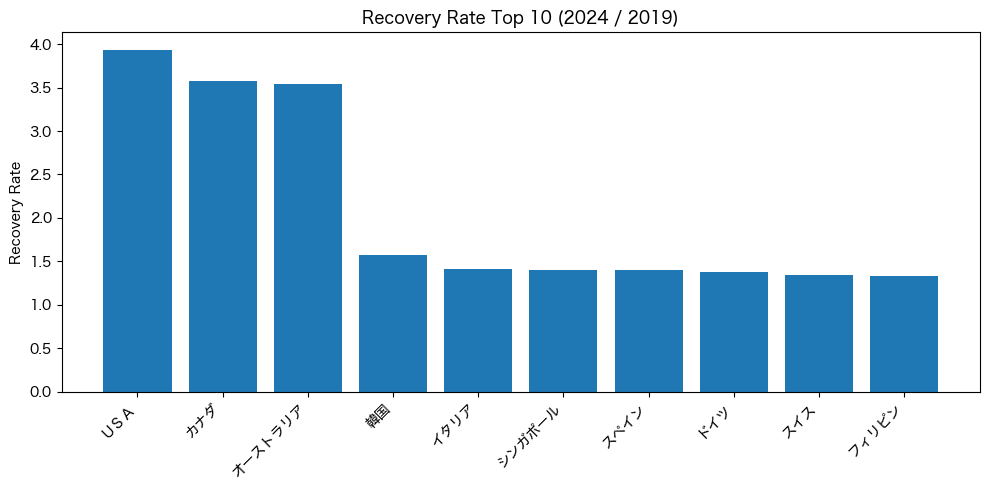

In [117]:
analyzer.plot_recovery(
    base_year=2019,
    compare_year=2024,
    top_n=10,
    mode="top",
    min_base_total=50000
)


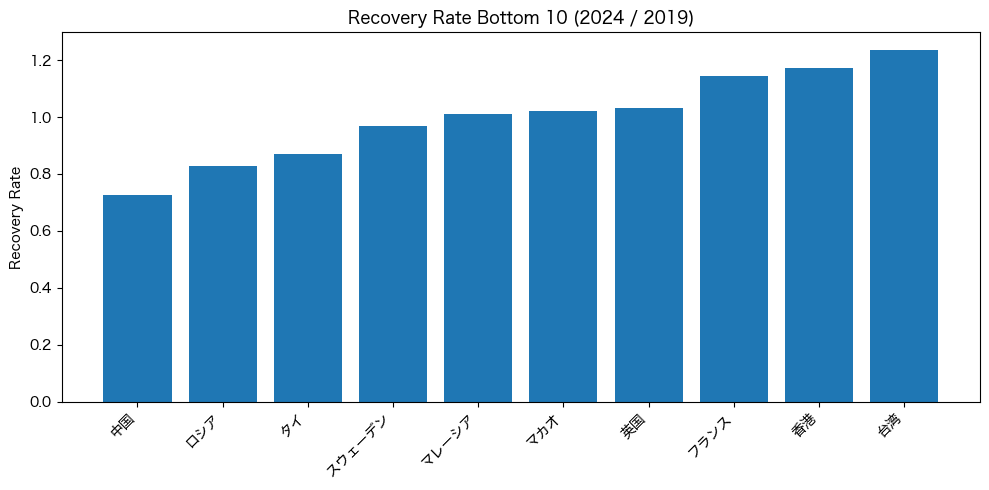

In [118]:
analyzer.plot_recovery(
    base_year=2019,
    compare_year=2024,
    top_n=10,
    mode="bottom",
    min_base_total=50000
)


In [114]:
df_recovery["recovery_rate"].describe()
# 一応

count    24.000000
mean      1.501395
std       0.870096
min       0.727648
25%       1.028220
50%       1.275233
75%       1.400729
max       3.938003
Name: recovery_rate, dtype: float64